# Week 6 - Bivariate Analysis, part 2

# 1. Lesson: no lesson this week

# 2. Weekly graph question

Suppose you wanted to show the nitrate and phosphate level in a water sample.  What are the advantages and disadvantages of showing this as an area plot, as opposed to two separate line graphs?  How would you adjust the graphs shown to improve the presentation?

In [93]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

Text(0, 0.5, 'Nitrate level (% of eutrophic value)')

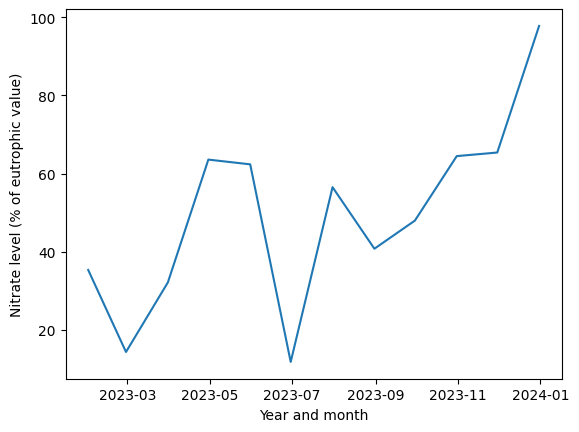

In [2]:
numdates = 12
np.random.seed(0)
time_series = 100 * (np.random.normal(size = numdates) / 5 + np.arange(numdates) / 16)
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='ME')
ax = sns.lineplot(x = datearray, y = time_series)
ax.set_xlabel("Year and month")
ax.set_ylabel("Nitrate level (% of eutrophic value)")

Text(0, 0.5, 'Phosphate level (% of eutrophic value)')

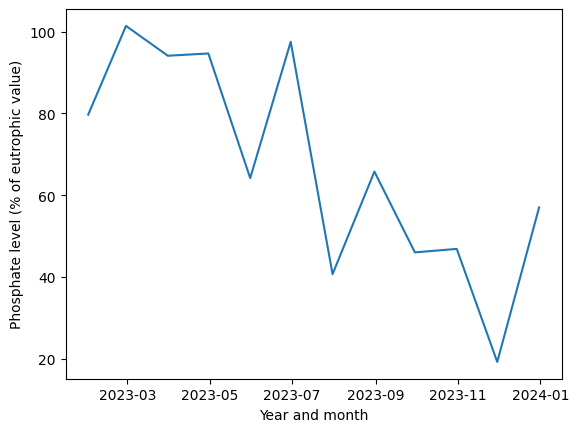

In [3]:
np.random.seed(1)
time_series_2 =  100 * (1 - (np.random.normal(size = numdates) / 8 + np.arange(numdates) / 16))
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='ME')
ax = sns.lineplot(x = datearray, y = time_series_2)
ax.set_xlabel("Year and month")
ax.set_ylabel("Phosphate level (% of eutrophic value)")

<Axes: >

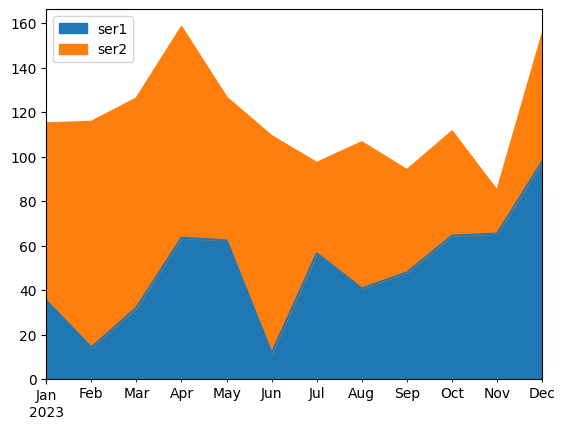

In [4]:
df = pd.DataFrame({'ser1': time_series, 'ser2': time_series_2}, index = datearray)
df.plot.area()

##### Response:

What are the advantages of showing this as an area plot?
- The area plot shows the volumes as well as the specific plots for each data point
- The top line helps you visualize the combined concentrations
- Visually, it can give you a sense of which chemical is more prevalent by looking at the magnitude of each of the filled in areas (and the proportionality of the chemical combinations)

What are the advantages of showing this as two separate line graphs?
- Easier to see the exact data points since it is not filled in like the area plots. Both are fine to analyze and understand the specific points because there are not many, but if this was a more granular dataset it might be more difficult for reading the points on an area plot. So in this case, a simpler line plot would be better.
- Two separate graphs makes it easier to understand the individual chemicals rates of change through time. Especially if they are side by side and with the same scaling for x and y it might be easier to compare the two.

What are the disadvantages of showing this as an area plot?
- If the areas are not stacked and the measurements are too similar, then it could hide the other chemical. It didn't happen in this case, but it's something to keep in mind when making area plots
- If the areas are stacked, it is more difficult to compare the trends between the chemicals since they are stacked to represent total volume rather than being precise with where the data points for the top layer would lie if they were not stacked.
- Depending on the person, the area plot could feel busier depending on how many groups of data are plotted on the graph. In this case, just with two it is fine. But adding more might make it more difficult to analyze and interpret.
- The lines are connected and makes the data between the points seem to be part of the dataset when in reality it is just a line connecting dots on a graph. This mean it is misrepresenting the data in between the data points.

What are the disadvantages of showing this as two separate line graphs?
- The view is more fragmented since they are plotted in two separate graphs rather than one. Depending on the data, it might be better to plot the two lines on the same graph with different colors for better comparison.
- The lines are connected and makes the data between the points seem to be part of the dataset when in reality it is just a line connecting dots on a graph. This mean it is misrepresenting the data in between the data points.

How would you adjust the graphs shown to improve the presentation?
- For the area plots, I would edit the legend to make it clear what chemicals the colors represent. I would also add a label for the y-axis to understand what is being measured.
- For the line graphs, I would put them into one graph and color based on the chemical type. That way you can analyze the slope of the data over time, see how the data points compare with one another, etc.


# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Find correlations between pairs of variables.

- Draw scatterplots, especially when the correlation is large.

- Draw pairplots.

- Draw line graphs and/or area graphs when there is date or time data together with numerical data.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If the data are not useable, find some new data!

- Do you see any outliers?  (Data points that are far from the rest of the data).

- Are any data items highly correlated with each other, suggesting that they are redundant?

- For the line plots, do you see a trend or pattern over time?  Does this suggest that the data are changing over time (drifting) in such a way as to invalidate comparisons?

- Can you think of any confounding variables?  (Third variables that could explain any correlations between other variables.  These third variables may or may not be reported in the dataset.)

In [5]:
# load dataset (individual files for race by sex)

cancer_female_asian = pd.read_csv('../Projects/Health Disparities Analytics/Data/Cancer/Female/County_Cancer_Asian_Female.csv', skiprows=8)     # skipping first 8 rows because it doesn't match the delimiter. Data header begins on row 9
cancer_female_black = pd.read_csv('../Projects/Health Disparities Analytics/Data/Cancer/Female/County_Cancer_Black_Female.csv', skiprows=8)
cancer_female_hispanic = pd.read_csv('../Projects/Health Disparities Analytics/Data/Cancer/Female/County_Cancer_Hispanic_Female.csv', skiprows=8)
cancer_female_native = pd.read_csv('../Projects/Health Disparities Analytics/Data/Cancer/Female/County_Cancer_NativeAmerican_Female.csv', skiprows=8)
cancer_female_white = pd.read_csv('../Projects/Health Disparities Analytics/Data/Cancer/Female/County_Cancer_White_Female.csv', skiprows=8)

cancer_male_asian = pd.read_csv('../Projects/Health Disparities Analytics/Data/Cancer/Male/County_Cancer_Asian_Male.csv', skiprows=8)
cancer_male_black = pd.read_csv('../Projects/Health Disparities Analytics/Data/Cancer/Male/County_Cancer_Black_Male.csv', skiprows=8)
cancer_male_hispanic = pd.read_csv('../Projects/Health Disparities Analytics/Data/Cancer/Male/County_Cancer_Hispanic_Male.csv', skiprows=8)
cancer_male_native = pd.read_csv('../Projects/Health Disparities Analytics/Data/Cancer/Male/County_Cancer_NativeAmerican_Male.csv', skiprows=8)
cancer_male_white = pd.read_csv('../Projects/Health Disparities Analytics/Data/Cancer/Male/County_Cancer_White_Male.csv', skiprows=8)

In [6]:
# Group df variables into a dictionary
cancer_datasets = {
    "Female - Asian":               cancer_female_asian,
    "Female - Black":               cancer_female_black,
    "Female - Hispanic":            cancer_female_hispanic,
    "Female - Native American":     cancer_female_native,
    "Female - White":               cancer_female_white,
    "Male - Asian":                 cancer_male_asian,
    "Male - Black":                 cancer_male_black,
    "Male - Hispanic":              cancer_male_hispanic,
    "Male - Native American":       cancer_male_native,
    "Male - White":                 cancer_male_white
}

# Loop through and print the name + info
for name, df in cancer_datasets.items():
    print(f"\n" + "="*40)
    print(f"DATASET: {name}")
    print("="*40 + '\n')
    df.info()


DATASET: Female - Asian

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3162 entries, 0 to 3161
Data columns (total 14 columns):
 #   Column                                                        Non-Null Count  Dtype  
---  ------                                                        --------------  -----  
 0   County                                                        3162 non-null   object 
 1   FIPS                                                          3144 non-null   float64
 2   2023 Rural-Urban Continuum Codes([rural urban note])          3143 non-null   object 
 3   Age-Adjusted Incidence Rate([rate note]) - cases per 100,000  3144 non-null   object 
 4   Lower 95% Confidence Interval                                 3144 non-null   object 
 5   Upper 95% Confidence Interval                                 3144 non-null   object 
 6   CI*Rank([rank note])                                          3144 non-null   object 
 7   Lower CI (CI*Rank)                         

Above: All datasets have same columns, datatypes. They mostly have the same non-null counts, however there are slight differences to keep in mind.

Note: for all datasets, they are from 2018-2022, all stages of cancer, all cancer sites, and the csv files are sorted by rate.

Cleaning: I will need to convert the datatypes in order to properly analyze the data. The datatypes are mostly objects rather than numerical types like floats or ints

In [7]:
# Now I am going to find the total counts of these placeholders to get a general idea of these potential disparities 
# (suppression due to too few counts, no public access to county level data, combined all racial data so you do not get a granular insight in Puerto Rico)

# The specific placeholders I am looking for
placeholders = ['*', '[P1 note]', '[P3 note]']

for name, df in cancer_datasets.items():
    print(f"\n{'='*50}")
    print(f"{name}")
    print(f"{'='*50}")
    
    # Get NaN counts per column
    nan_counts = df.isna().sum()
    
    # 2. Placeholder counts per column
    placeholder_counts = df.apply(lambda col: col.astype(str).str.strip().isin(placeholders).sum())
    
    # Combine results into a DF
    summary = pd.DataFrame({
        'Real NaNs': nan_counts,
        'Placeholders': placeholder_counts,
        'Total Missing & Generalized Racial Data': nan_counts + placeholder_counts
    })
    
    # Only show columns that actually have missing data to keep it clean
    print(summary[summary['Total Missing & Generalized Racial Data'] > 0])


Female - Asian
                                                    Real NaNs  Placeholders  \
FIPS                                                       18             0   
2023 Rural-Urban Continuum Codes([rural urban n...         19             0   
Age-Adjusted Incidence Rate([rate note]) - case...         18          2597   
Lower 95% Confidence Interval                              18          2597   
Upper 95% Confidence Interval                              18          2597   
CI*Rank([rank note])                                       18          2491   
Lower CI (CI*Rank)                                         18          2491   
Upper CI (CI*Rank)                                         18          2491   
Average Annual Count                                       18           106   
Recent Trend                                               18          2791   
Recent 5-Year Trend ([trend note]) in Incidence...         18          2791   
Lower 95% Confidence Interval.1     

In [8]:
# Looking at what these placeholder symbols are in some of the columns

print(f"Recent Trend: {cancer_female_asian['Recent Trend'].unique()} \n")
print(f"Recent 5-Year Trend ([trend note]) in Incidence Rates: {cancer_female_asian['Recent 5-Year Trend ([trend note]) in Incidence Rates'].unique()} \n")
print(f"Lower 95% Confidence Interval.1: {cancer_female_asian['Lower 95% Confidence Interval.1'].unique()} \n")
print(f"Upper 95% Confidence Interval.1: {cancer_female_asian['Upper 95% Confidence Interval.1'].unique()} \n")

Recent Trend: ['rising' '*' 'stable' 'falling' '[P1 note]' '[P3 note]' nan] 

Recent 5-Year Trend ([trend note]) in Incidence Rates: ['0.5 ' '*' '2.6 ' '2.7 ' '1.0 ' '0.9 ' '-0.3 ' '1.9 ' '2.1 ' '1.2 '
 '0.2 ' '2.3 ' '2.5 ' '0.6 ' '1.6 ' '2.8 ' '7.7 ' '1.1 ' '2.2 ' '3.4 '
 '4.0 ' '-0.4 ' '1.3 ' '1.8 ' '1.7 ' '0.4 ' '0.3 ' '-1.5 ' '-0.2 ' '2.0 '
 '-0.7 ' '3.1 ' '-0.5 ' '1.4 ' '0.7 ' '14.6 ' '1.5 ' '4.1 ' '0.8 ' '-7.7 '
 '-4.1 ' '0.0 ' '-0.6 ' '-2.4 ' '8.1 ' '-0.9 ' '3.0 ' '-1.9 ' '10.3 '
 '3.2 ' '0.1 ' '-2.2 ' '3.5 ' '-11.2 ' '-1.1 ' '3.6 ' '3.8 ' '-4.6 '
 '-6.3 ' '-0.1 ' '2.4 ' '5.0 ' '-9.4 ' '-1.8 ' '11.5 ' '-2.9 ' '-1.4 '
 '-0.8 ' '-6.0 ' '-1.2 ' '-1.6 ' '-5.1 ' '-2.7 ' '2.9 ' '-10.5 ' '-3.4 '
 '-5.5 ' '-3.3 ' '-3.1 ' '5.1 ' '-3.7 ' '-1.0 ' '-2.0 ' '-3.0 ' '-5.4 '
 '4.5 ' '-2.5 ' '-11.1 ' '-2.1 ' '-3.6 ' '-2.8 ' '-1.3 ' '-3.2 '
 '[P1 note]' '[P3 note]' nan] 

Lower 95% Confidence Interval.1: ['0.4' '*' '0.6' '-1.1' '-2.8' '-1.5' '-4.8' '-0.9' '-2.6' '-5.7' '0.3'
 '0.0' '-1.2' '-2.4' 

#### non-numerical unique values: *, [P1 note], [P3 note] - (Information found at the bottom of each CSV file)

##### Asterisk (*):
- "* Data has been suppressed to ensure confidentiality and stability of rate estimates. Counts are suppressed if fewer than 16 records were reported in a specific area-sex-race category."


##### [P1 note]:
-"[P1 note] Data not available because of state legislation and regulations which prohibit the release of county level data to outside entities."


##### [P3 note]:
"[P3 note] Data for Puerto Rico is only available for All Races (includes Hispanics) For more information see data not available https://statecancerprofiles.cancer.gov/datanotavailable.html"


###### Source for more information on health data supression: [CDC](https://www.cdc.gov/united-states-cancer-statistics/technical-notes/suppression.html?CDC_AAref_Val=https://www.cdc.gov/cancer/uscs/technical_notes/stat_methods/suppression.htm)

In [9]:
# Need a schema for dealing with the *, [P1 note], and [P3 note] placeholders. Assign them to a number way outside of the range of the numbers in order to differentiate between them.

# Mapping dictionary for the replacement
flag_map = {
    '*': -9999,
    '[P1 note]': -9998,
    '[P3 note]': -9997
}

for name, df in cancer_datasets.items():

    for col in df.columns:
        if df[col].dtype == 'object':

            # map the placeholders to the flag_map values
            df[col] = df[col].astype(str).str.strip().replace(flag_map)

            # Convert column to numeric if it can be, else ignore it (ex. County column where the values are strings)
            try:
                df[col] = pd.to_numeric(df[col])
            except (ValueError, TypeError):
                continue


In [10]:
cancer_female_asian.head()

,County,FIPS,2023 Rural-Urban Continuum Codes([rural urban note]),"Age-Adjusted Incidence Rate([rate note]) - cases per 100,000",Lower 95% Confidence Interval,Upper 95% Confidence Interval,CI*Rank([rank note]),Lower CI (CI*Rank),Upper CI (CI*Rank),Average Annual Count,Recent Trend,Recent 5-Year Trend ([trend note]) in Incidence Rates,Lower 95% Confidence Interval.1,Upper 95% Confidence Interval.1
0,US (SEER+NPCR)(1),0.0,nan,308.9,307.4,310.3,N/A,N/A,N/A,37611,rising,0.5,0.4,0.6
1,"Wagoner County, Oklahoma(2)",40145.0,Urban,760.8,421.4,1233.8,N/A,N/A,N/A,4,-9999,-9999,-9999,-9999
2,"Cascade County, Montana(2)",30013.0,Urban,646.9,392.2,1006.2,N/A,N/A,N/A,5,-9999,-9999,-9999,-9999
3,"Tuolumne County, California(7)",6109.0,Rural,616.2,261.8,1185.3,N/A,N/A,N/A,4,-9999,-9999,-9999,-9999
4,"Hoke County, North Carolina(2)",37093.0,Urban,586.3,320.2,982.9,N/A,N/A,N/A,3,-9999,-9999,-9999,-9999


In [11]:
# Extract State from the County column in order to conduct state cancer data analysis as well

delimiter = ', '    # delimiter for the county string format '(County Name), (State Name)(#)'

for name, df in cancer_datasets.items():

    df.loc[1:, 'State'] = (
        df.loc[1:, 'County']
        .str.extract(r',\s*([^(\n]+)')      # Extracts everything between ', ' and '('
        .iloc[:, 0]                         # Convert from DataFrame to Series
        .str.strip()
    )

    # Clean County column without the State name
    df.loc[1:, 'County_Clean'] = (
        df.loc[1:, 'County']
        .str.split(',').str[0]
        .str.strip()
        .str.split(' ').str[0]              # gets rid of 'County' after the county name
    )

# Let's see the result for the first dataset
print(cancer_datasets["Female - Asian"][['County', 'County_Clean', 'State']].head(10))

                           County County_Clean           State
0               US (SEER+NPCR)(1)          NaN             NaN
1     Wagoner County, Oklahoma(2)      Wagoner        Oklahoma
2      Cascade County, Montana(2)      Cascade         Montana
3  Tuolumne County, California(7)     Tuolumne      California
4  Hoke County, North Carolina(2)         Hoke  North Carolina
5     Chemung County, New York(7)      Chemung        New York
6    Erie County, Pennsylvania(2)         Erie    Pennsylvania
7      Jackson County, Georgia(7)      Jackson         Georgia
8           Scott County, Iowa(7)        Scott            Iowa
9    Nevada County, California(7)       Nevada      California


AI usage: Used Gemini to help with this task of extracting state names from the county column

https://gemini.google.com/share/b7bda4b8e4f6

# --------------- Bivariate Analysis --------------- 

In [12]:
cancer_female_asian.sample(5)

,County,FIPS,2023 Rural-Urban Continuum Codes([rural urban note]),"Age-Adjusted Incidence Rate([rate note]) - cases per 100,000",Lower 95% Confidence Interval,Upper 95% Confidence Interval,CI*Rank([rank note]),Lower CI (CI*Rank),Upper CI (CI*Rank),Average Annual Count,Recent Trend,Recent 5-Year Trend ([trend note]) in Incidence Rates,Lower 95% Confidence Interval.1,Upper 95% Confidence Interval.1,State,County_Clean
13,"Chelan County, Washington(2)",53007.0,Urban,466.9,264.2,776.6,N/A,N/A,N/A,3,-9999,-9999,-9999,-9999,Washington,Chelan
1305,"Foster County, North Dakota(2)",38031.0,Rural,-9999,-9999,-9999,-9999,-9999,-9999,3 or fewer,-9999,-9999,-9999,-9999,North Dakota,Foster
2032,"McCracken County, Kentucky(7)",21145.0,Urban,-9999,-9999,-9999,-9999,-9999,-9999,3 or fewer,-9999,-9999,-9999,-9999,Kentucky,McCracken
282,"Kauai County, Hawaii(7)",15007.0,Rural,296.2,267.6,327.2,N/A,N/A,N/A,87,stable,-0.3,-1.2,0.6,Hawaii,Kauai
517,"Benton County, Arkansas(2)",5007.0,Urban,211.6,147.7,293.8,N/A,N/A,N/A,10,-9999,-9999,-9999,-9999,Arkansas,Benton


In [13]:
# Filter for Massachusetts
ma_df = cancer_female_asian[cancer_female_asian['State'] == 'Massachusetts'].copy()

ma_df['County_Clean'].unique()

array(['Worcester', 'Essex', 'Norfolk', 'Middlesex', 'Hampden',
       'Barnstable', 'Plymouth', 'Suffolk', 'Berkshire', 'Bristol',
       'Hampshire', 'Dukes', 'Franklin', 'Nantucket'], dtype=object)

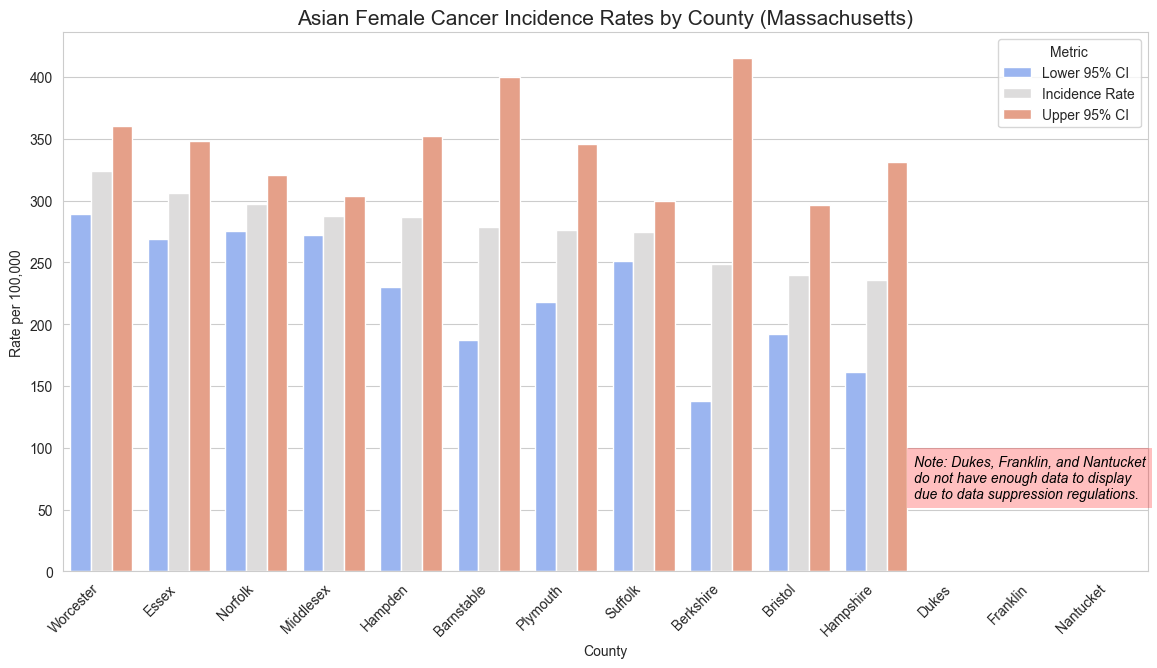

In [14]:
# Columns to graph
rate_col = 'Age-Adjusted Incidence Rate([rate note]) - cases per 100,000'
lower_ci = 'Lower 95% Confidence Interval'
upper_ci = 'Upper 95% Confidence Interval'

# Clean data so if the placeholder values exist (<= -9997)
for col in [rate_col, lower_ci, upper_ci]:
    # Ensure numeric conversion (handling strings and your -9999 flags)
    ma_df[col] = pd.to_numeric(ma_df[col], errors='coerce')
    
    # TREAT PLACEHOLDERS AS 0:
    # Any value we flagged as -9999, -9998, or -9997 is now set to 0.0
    ma_df.loc[ma_df[col] <= -9997, col] = 0.0
    
    # Also fill any NaN (just in case) with 0.0 to ensure they show up as 0-height bars
    ma_df[col] = ma_df[col].fillna(0.0)

# Reshape for Seaborn
# This turns 3 columns into two: 'Metric' (the type) and 'Value' (the number)
df_long = ma_df.melt(
    id_vars=['County_Clean'], 
    value_vars=[lower_ci, rate_col, upper_ci],
    var_name='Metric', 
    value_name='Rate'
)

# Create the Plot
plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")

ax = sns.barplot(
    data=df_long, 
    x='County_Clean', 
    y='Rate', 
    hue='Metric',
    palette='coolwarm'
)

plt.title('Asian Female Cancer Incidence Rates by County (Massachusetts)', fontsize=15)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Rate per 100,000')
plt.xlabel('County')

# Clean up the legend labels so they aren't so long
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ['Lower 95% CI', 'Incidence Rate', 'Upper 95% CI'], title='Metric')

# Added note for missing bars
plt.figtext(0.733, 0.215, 
            'Note: Dukes, Franklin, and Nantucket\ndo not have enough data to display\ndue to data suppression regulations.', 
            horizontalalignment='left', 
            fontsize=10, 
            color='black', 
            style='italic',
            bbox={'facecolor': 'red', 'alpha': 0.25, 'pad': 5, 'edgecolor': 'none'})

plt.show()

In [15]:
print(cancer_female_asian.dtypes)

County                                                           object
FIPS                                                            float64
2023 Rural-Urban Continuum Codes([rural urban note])             object
Age-Adjusted Incidence Rate([rate note]) - cases per 100,000     object
Lower 95% Confidence Interval                                    object
Upper 95% Confidence Interval                                    object
CI*Rank([rank note])                                             object
Lower CI (CI*Rank)                                               object
Upper CI (CI*Rank)                                               object
Average Annual Count                                             object
Recent Trend                                                     object
Recent 5-Year Trend ([trend note]) in Incidence Rates            object
Lower 95% Confidence Interval.1                                  object
Upper 95% Confidence Interval.1                                 

In [16]:
numeric_cols = [
    'Age-Adjusted Incidence Rate([rate note]) - cases per 100,000',
    'Lower 95% Confidence Interval',
    'Upper 95% Confidence Interval',
    'Average Annual Count',
    'Recent 5-Year Trend ([trend note]) in Incidence Rates'
]

for col in numeric_cols:
    if col in cancer_female_asian.columns:

        # Convert to numeric, turn errors to NaN
        cancer_female_asian[col] = pd.to_numeric(cancer_female_asian[col], errors='coerce')
        
        # Temporarily turn flags into NaN for the pairplot
        cancer_female_asian.loc[cancer_female_asian[col] <= -9997, col] = np.nan

# Create a mapping of long names to concise labels
rename_map = {
    '2023 Rural-Urban Continuum Codes([rural urban note])': '2023 Rural-Urban Code',
    'Age-Adjusted Incidence Rate([rate note]) - cases per 100,000': 'Incidence Rate per 100K',
    'Lower 95% Confidence Interval': 'Lower 95% CI',
    'Upper 95% Confidence Interval': 'Upper 95% CI',
    'CI*Rank([rank note])': 'Rank',
    'Lower CI (CI*Rank)': 'Rank Lower CI',
    'Upper CI (CI*Rank)': 'Rank Upper CI',
    'Recent 5-Year Trend ([trend note]) in Incidence Rates': '5-Year Incidence Rate',
    'Lower 95% Confidence Interval.1': 'Trend Lower 95% CI',
    'Upper 95% Confidence Interval.1': 'Trend Upper 95% CI'
}

cancer_female_asian = cancer_female_asian.rename(columns=rename_map)

for name in cancer_datasets:
    cancer_datasets[name] = cancer_datasets[name].rename(columns=rename_map)


new_numeric_cols = [
    'Incidence Rate per 100K', 
    'Lower 95% CI', 
    'Upper 95% CI', 
    '5-Year Incidence Rate', 
    'Average Annual Count'
]

plot_df = cancer_female_asian[new_numeric_cols].copy()


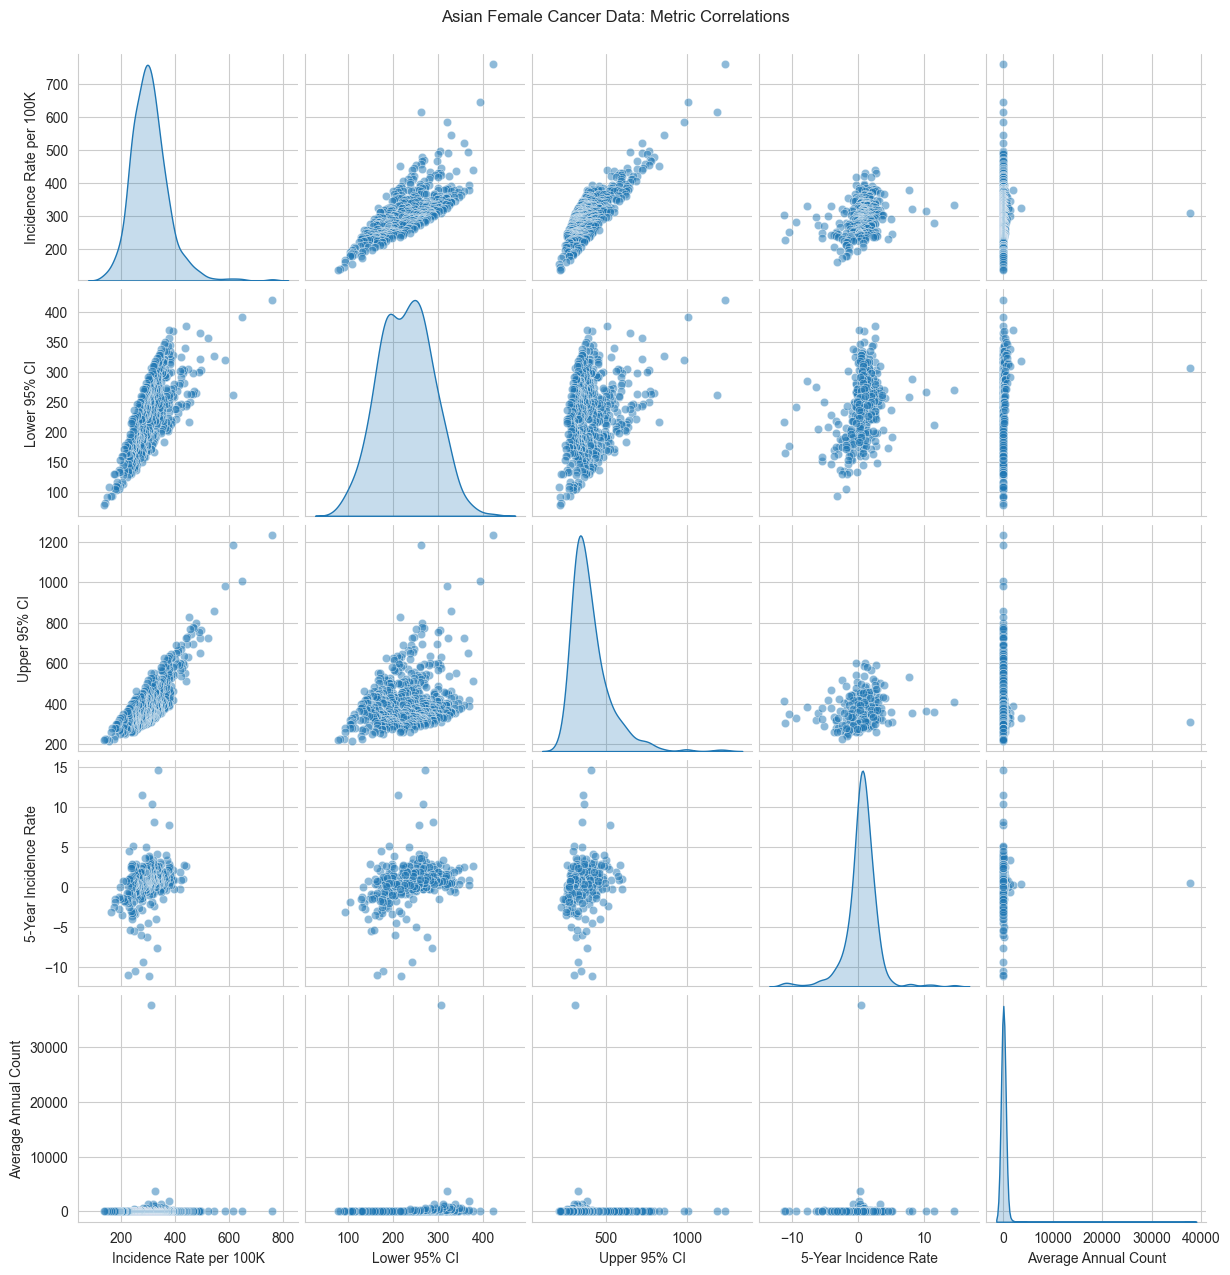

In [17]:
sns.pairplot(plot_df, diag_kind='kde', plot_kws={'alpha': 0.5})
plt.suptitle('Asian Female Cancer Data: Metric Correlations', y=1.02)
plt.show()

After cleaning the dataset for plotting the pairplot, you can see in row 4 and column 4 that the Average Annual Count scale is being stretched out due to one outlier county with a significantly larger average annual count. I will redo this plot with a log form of this column for better representation of the data.

In [18]:
cancer_female_asian.columns

Index(['County', 'FIPS', '2023 Rural-Urban Code', 'Incidence Rate per 100K',
       'Lower 95% CI', 'Upper 95% CI', 'Rank', 'Rank Lower CI',
       'Rank Upper CI', 'Average Annual Count', 'Recent Trend',
       '5-Year Incidence Rate', 'Trend Lower 95% CI', 'Trend Upper 95% CI',
       'State', 'County_Clean'],
      dtype='object')

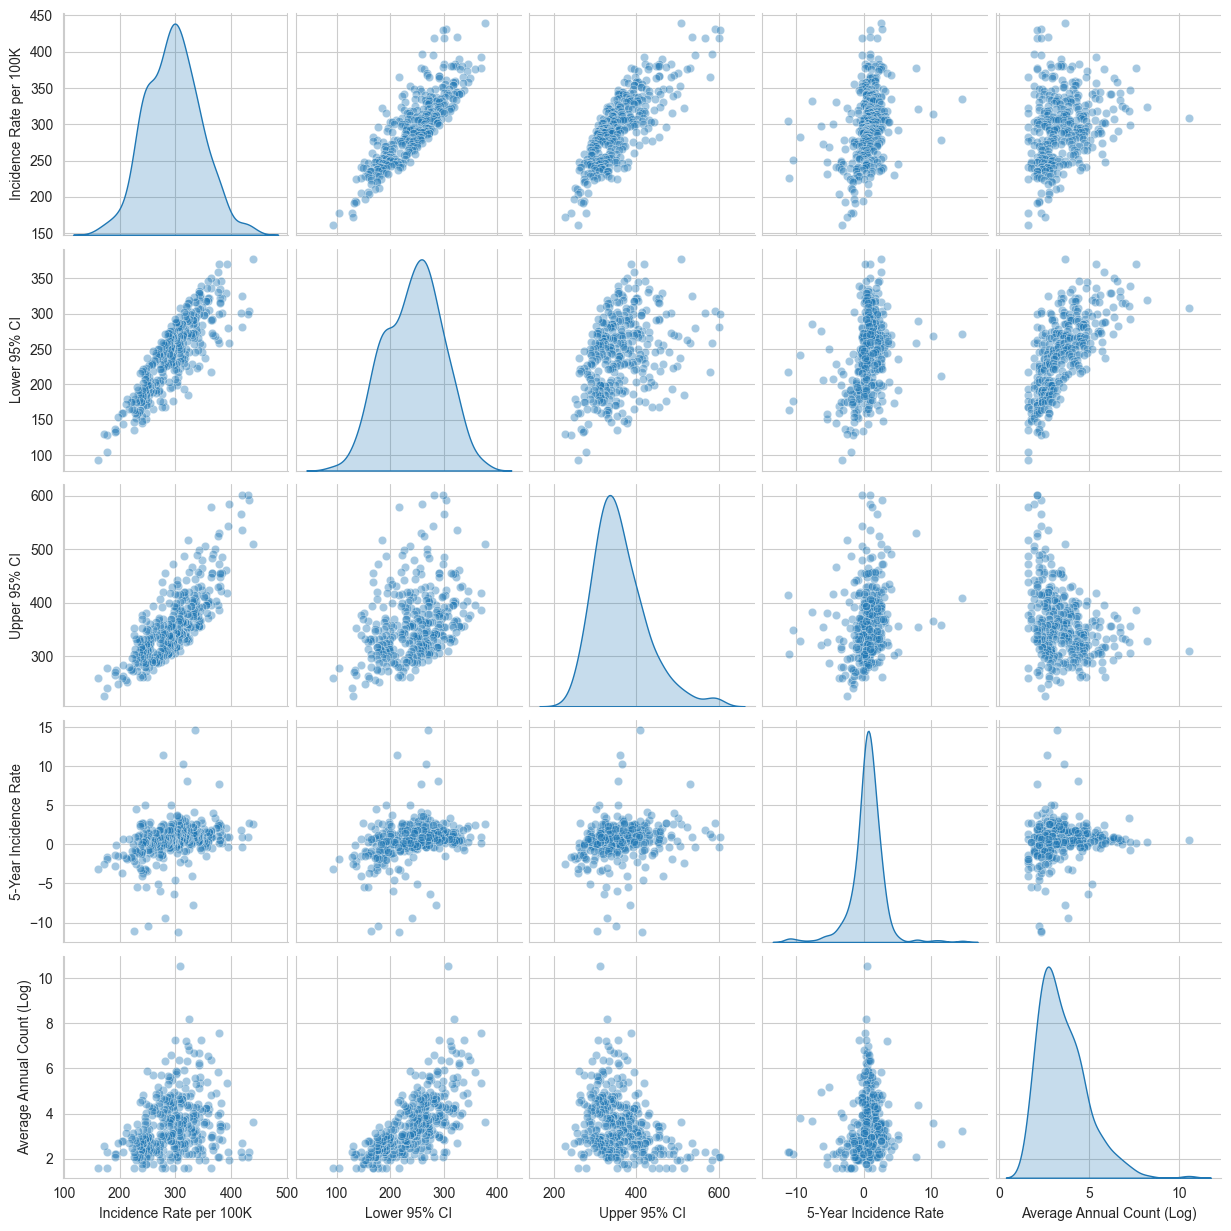

In [19]:
plot_df_log = cancer_female_asian[new_numeric_cols].copy()

plot_df_log['Average Annual Count (Log)'] = np.log1p(plot_df_log['Average Annual Count'])

plot_df_log = plot_df_log.drop(columns=['Average Annual Count'])

sns.pairplot(plot_df_log.dropna(), diag_kind='kde', plot_kws={'alpha': 0.4})

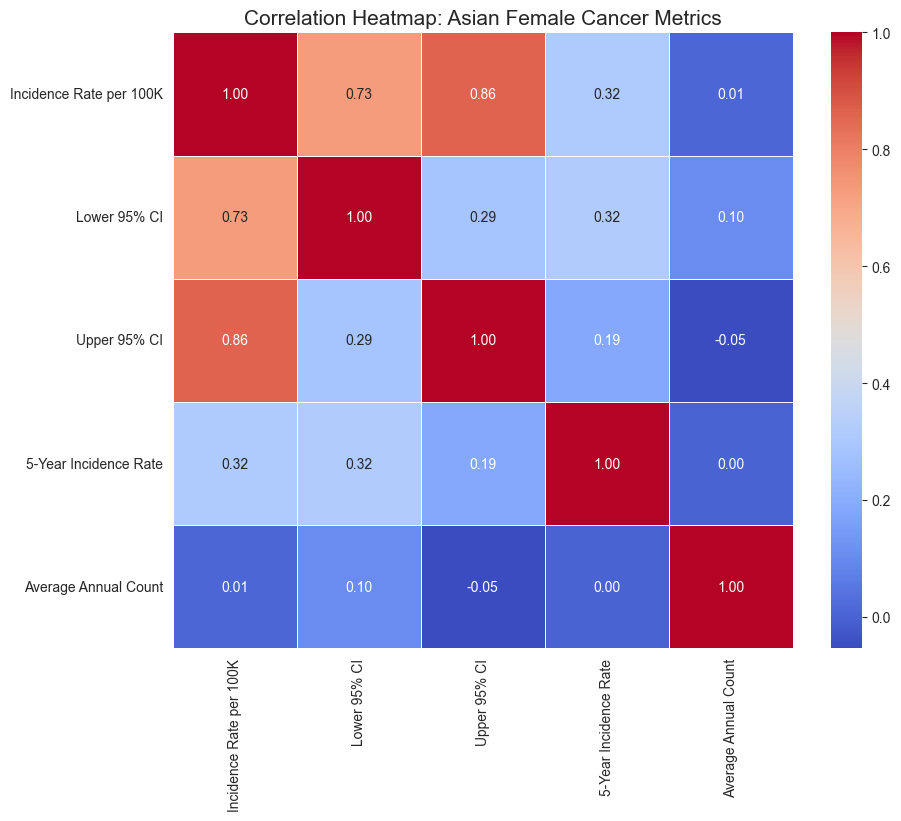

In [21]:
correlation_matrix = cancer_female_asian[new_numeric_cols].corr()

plt.figure(figsize=(10, 8))

# Create the heatmap
sns.heatmap(
    correlation_matrix, 
    annot=True,          # Show the actual correlation numbers
    cmap='coolwarm',     # Red for positive, Blue for negative
    fmt=".2f",           # Limit to 2 decimal places
    linewidths=0.5
)

plt.title('Correlation Heatmap: Asian Female Cancer Metrics', fontsize=15)
plt.show()

### Conclusions:

The dataset has a lot of cleaning and datatype conversions to do before being able to properly analyze it. However, I think this data is very useable because it provides a lot of valuable information on cancer rates per county. I will need to consider how to deal wth the data supression and flagged data that might not be as accurate before creating models with this data.

There are some outliers such as the counties with a significantly larger Average Annual Count. This may be due to the fact that the county just has a significantly larger population so there are higher cancer counts. However, further analysis will be needed to determine if this is the truth or if there is a disparity in that county.

As for correlations, the Incidence Rate per 100K and Upper 95% CI has a very strong positive correlation. This makes sense because as the rate increases, the upper boundary of the confidence levels increases as well. The same logic applies with the strong correlation of the Incidence Rate per 100K and Lower 95% CI. This means there is signficant redundancy between these specific columns because confidence intervals are calculated from the incidence rate and the average annual count. So naturally, the CIs contain much of the same information.

---

In [24]:
life_expectancy_birth = pd.read_csv('../Projects/Health Disparities Analytics/Data/Life Expectancy at Birth/NCHS_-_Death_rates_and_life_expectancy_at_birth.csv') 
life_expectancy_birth.head()

,Year,Race,Sex,Average Life Expectancy (Years),Age-adjusted Death Rate
0,1900,All Races,Both Sexes,47.3,2518.0
1,1901,All Races,Both Sexes,49.1,2473.1
2,1902,All Races,Both Sexes,51.5,2301.3
3,1903,All Races,Both Sexes,50.5,2379.0
4,1904,All Races,Both Sexes,47.6,2502.5


In [25]:
life_expectancy_birth['Race'].unique()

array(['All Races', 'Black', 'White'], dtype=object)

As mentioned in a previous HW, the racial data is not granular enough since it only mentions All Races, Black, White. I will supplement this data with another dataset. But for now, I will analyze this dataset.

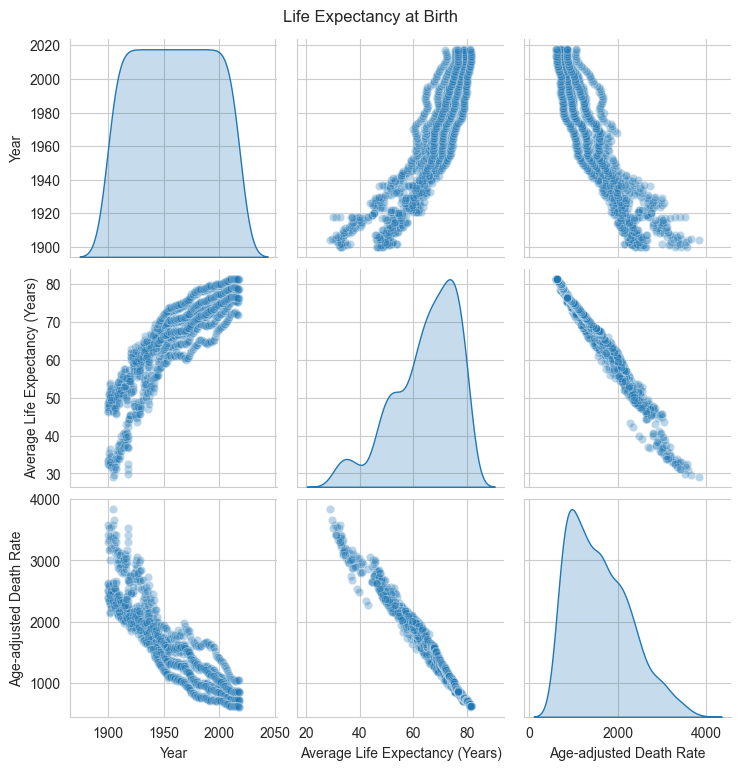

In [31]:
g = sns.pairplot(
    life_expectancy_birth, 
    diag_kind='kde', 
    plot_kws={
        'alpha': 0.3,    # Changes transparency of dots
    }
)

# Title and formatting
plt.suptitle('Life Expectancy at Birth', y=1.02)
plt.show()

- Average Life Expectancy has a very strong negative correlation with Age-adjusted Death Rate.
- Year and Average Life Expectancy has a positive exponential correlation
- Year and Age-adjusted Death Rate has a negative exponential correlation

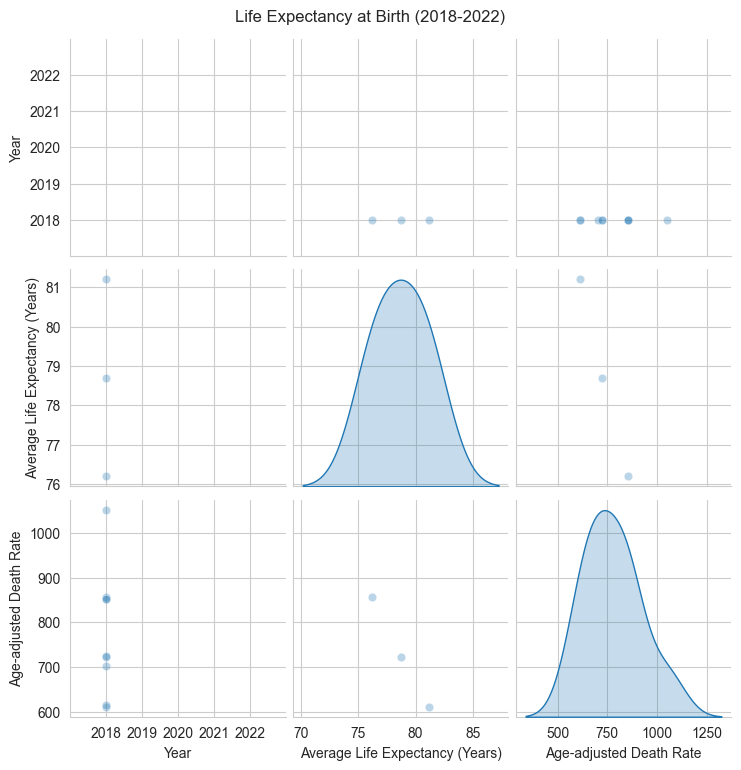

In [33]:
# Analyze the data in the time frame of the cancer datasets (2018-2022)

recent_life_expectancy = life_expectancy_birth[(life_expectancy_birth['Year'] >= 2018) & 
                               (life_expectancy_birth['Year'] <= 2022)]

g = sns.pairplot(
    recent_life_expectancy, 
    diag_kind='kde', 
    plot_kws={
        'alpha': 0.3,    # Changes transparency of dots
    }
)

# Fix the Year axis scaling so the 2018-2022 pattern is visible
for ax in g.axes.flatten():
    # Check if the x-axis or y-axis is 'Year' and zoom in
    if ax.get_xlabel() == 'Year':
        ax.set_xlim(2017, 2023)
        ax.set_xticks([2018, 2019, 2020, 2021, 2022])
    if ax.get_ylabel() == 'Year':
        ax.set_ylim(2017, 2023)
        ax.set_yticks([2018, 2019, 2020, 2021, 2022])

# Title and formatting
plt.suptitle('Life Expectancy at Birth (2018-2022)', y=1.02)
plt.show()

There is not enough data for these years to justify using it alongside the cancer datasets that are from 2018-2022. Either I would need to use this data and make a prediction of the columns for these time frames based on the historical data since the life expectancy dataset starts in the beginning of the 1900s or I need new data that matches the needed timeframe.

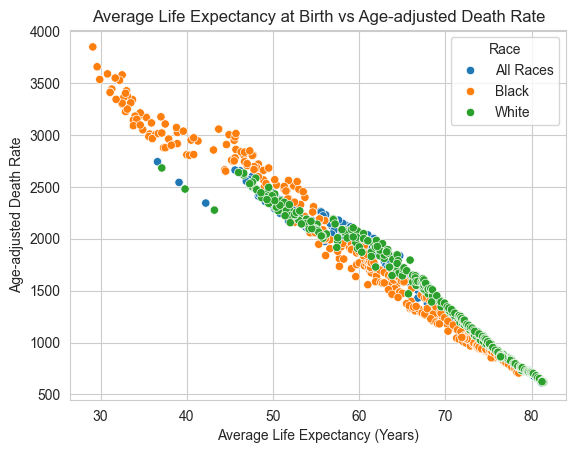

In [44]:
sns.scatterplot(life_expectancy_birth, x='Average Life Expectancy (Years)', y='Age-adjusted Death Rate', hue='Race')
plt.title('Average Life Expectancy at Birth vs Age-adjusted Death Rate')
plt.show()

There is a significant spread in average life expectancy when comparing Black people and White people. This shows that there is a disparity in life outcome because Black people have an average life expectancy from roughly 28-80 years while White people is roughly 38-82. 

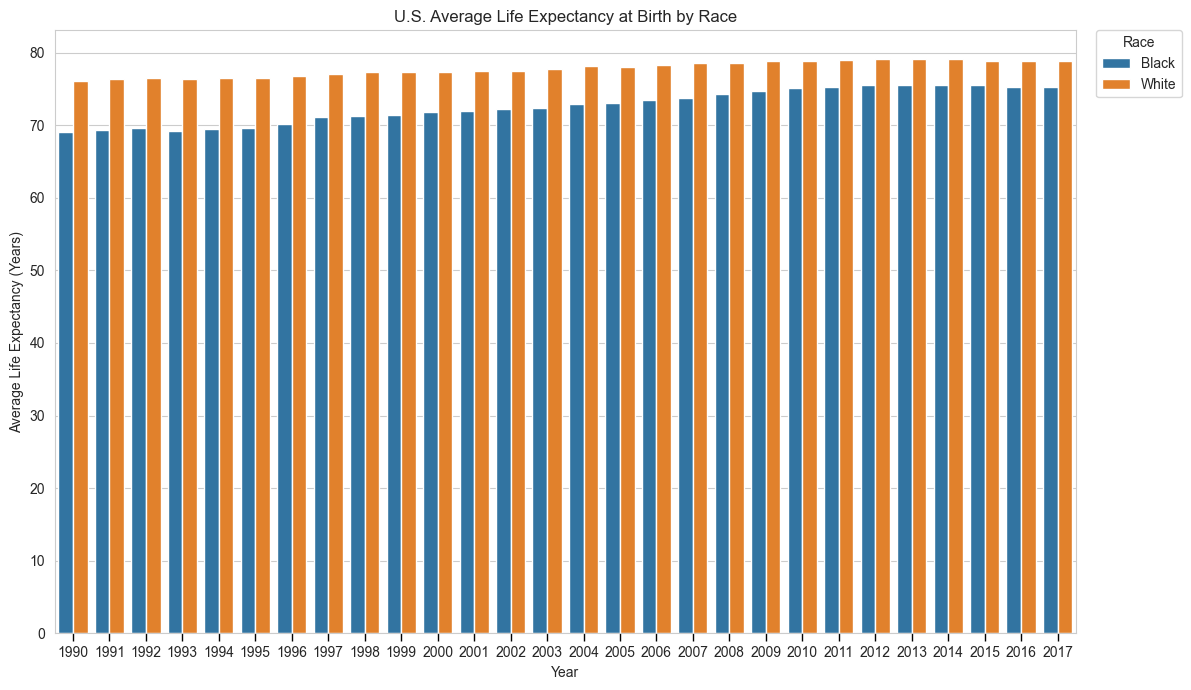

In [ ]:
plot_df = life_expectancy_birth[
    (life_expectancy_birth['Year'] >= 1990) & 
    (life_expectancy_birth['Year'] <= 2017) &
    (life_expectancy_birth['Sex'] == 'Both Sexes') &
    ((life_expectancy_birth['Race'] == 'Black') | (life_expectancy_birth['Race'] == 'White'))
]

plt.figure(figsize=(12, 7))
ax = sns.barplot(
    data=plot_df, 
    x='Year', 
    y='Average Life Expectancy (Years)', 
    hue='Race'
)

# This explicitly turns on the tick lines, sets their color to black, and gives them width
ax.tick_params(axis='x', which='both', bottom=True, length=6, color='black', width=1)

plt.legend(title='Race', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

plt.title('U.S. Average Life Expectancy at Birth by Race')
plt.tight_layout()
plt.show()

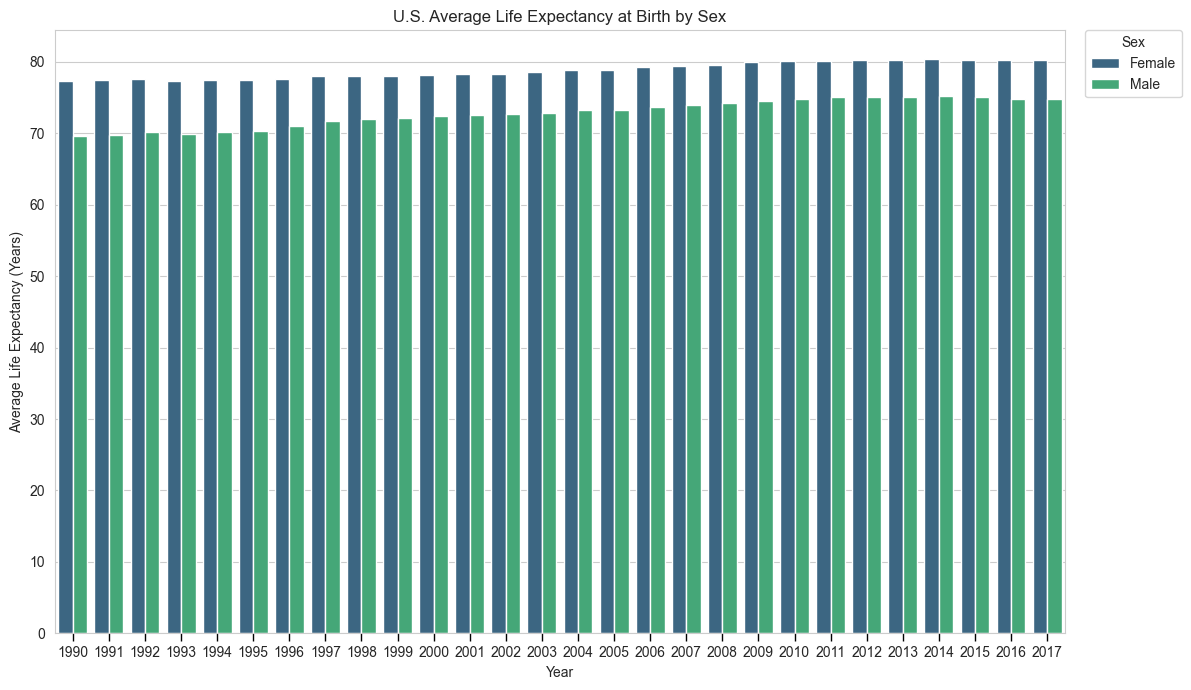

In [77]:
plot_df = life_expectancy_birth[
    (life_expectancy_birth['Year'] >= 1990) & 
    (life_expectancy_birth['Year'] <= 2017) &
    ((life_expectancy_birth['Sex'] == 'Female') | (life_expectancy_birth['Sex'] == 'Male'))
]

plt.figure(figsize=(12, 7))
ax = sns.barplot(
    data=plot_df, 
    x='Year', 
    y='Average Life Expectancy (Years)', 
    hue='Sex',
    palette='viridis',
    errorbar=None  # This removes the black lines
)

# This explicitly turns on the tick lines, sets their color to black, and gives them width
ax.tick_params(axis='x', which='both', bottom=True, length=6, color='black', width=1)

plt.legend(title='Sex', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

plt.title('U.S. Average Life Expectancy at Birth by Sex')
plt.tight_layout()
plt.show()

In [79]:
life_expectancy_birth.columns

Index(['Year', 'Race', 'Sex', 'Average Life Expectancy (Years)',
       'Age-adjusted Death Rate'],
      dtype='object')

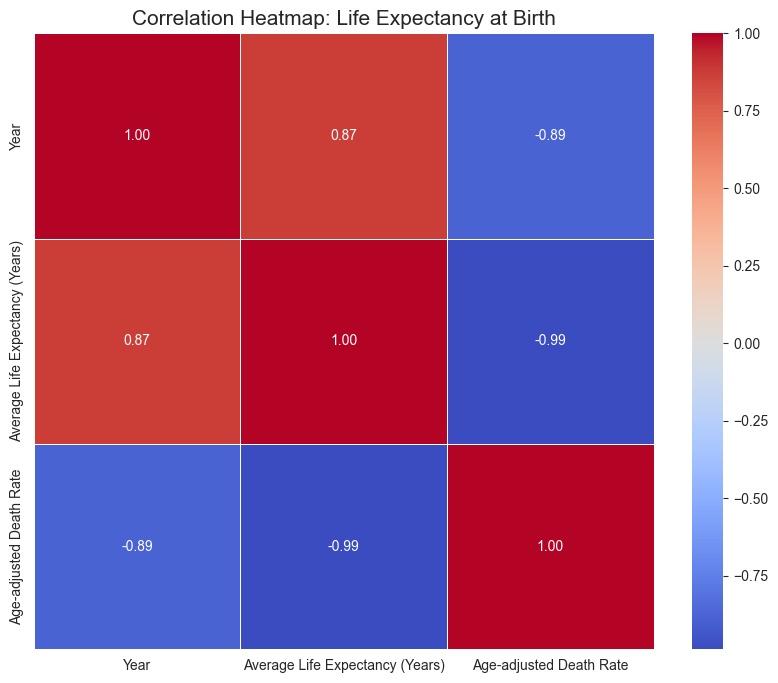

In [80]:
numeric_cols_expectancy = [
    'Year',
    'Average Life Expectancy (Years)',
    'Age-adjusted Death Rate'
]

correlation_matrix = life_expectancy_birth[numeric_cols_expectancy].corr()

plt.figure(figsize=(10, 8))

# Create the heatmap
sns.heatmap(
    correlation_matrix, 
    annot=True,          # Show the actual correlation numbers
    cmap='coolwarm',     # Red for positive, Blue for negative
    fmt=".2f",           # Limit to 2 decimal places
    linewidths=0.5
)

plt.title('Correlation Heatmap: Life Expectancy at Birth', fontsize=15)
plt.show()

- There is a strong negative correlation with Year and Age-adjusted Death Rate.
- There is a strong positive correlation with Year and Average Life Expectancy (Years)
- There is almost a near perfect negative correlation with Average Life Expectancy (Years) and Age-adjusted Death Rates.

### Conclusions:

I think this data is somewhat useable because it provides a lot of valuable information on for life expectancy and death rates by year for a more macro perspective. The most useful parts will be the different rates for Sex. However, the race category is quite limited since it only has 3 options rather than having a more granular racial setup. 

As for correlations, there are very strong correlations which make sense because they all have to do with lifespans and deaths.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 86-98 of the Storytelling With Data book as best you can.  (The second half of chapter three).  You do not have to get the exact data values right, just the overall look and feel.

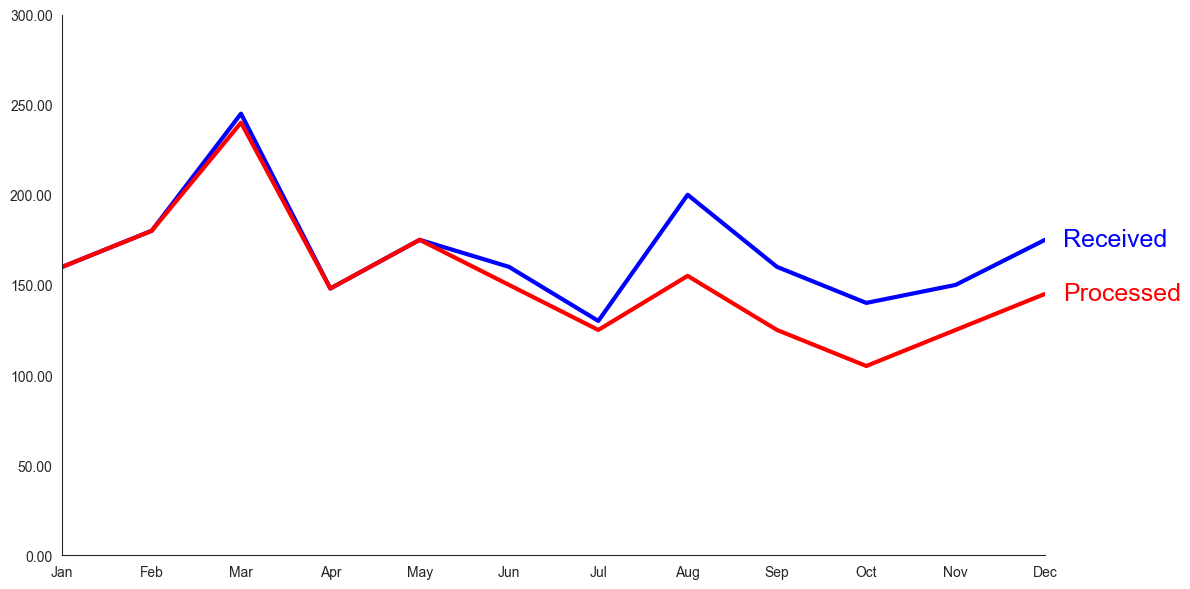

In [98]:
received = [160, 180, 245, 148, 175, 160, 130, 200, 160, 140, 150, 175]
processed = [160, 180, 240, 148, 175, 150, 125, 155, 125, 105, 125, 145]


months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul',
          'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

plt.figure(figsize=(12, 6))
sns.set_style("white")

sns.lineplot(x=months, y=received, color='blue', linewidth=3)
sns.lineplot(x=months, y=processed, color='red', linewidth=3)

# This forces the first month to the absolute left corner
plt.xlim(0, len(months) - 1)

plt.ylim(0.00, 300.00)
plt.yticks(range(0, 301, 50))

# Format y-axis to X.00
ax = plt.gca()
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f'))

# This removes the top and right spines by default
sns.despine()

plt.text(len(months) - 0.8, received[-1], 'Received', color='blue', 
         fontsize=18, va='center')

plt.text(len(months) - 0.8, processed[-1], 'Processed', color='red', 
         fontsize=18, va='center')

plt.tight_layout()
plt.show()